# --- CELL 1: Imports and Settings ---

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import copy

# Setting options for better visibility during EDA
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) # Restricted for readability

# --- CELL 2: Directory Setup ---

In [2]:
# Define the path to your data source
base_dir = Path(r"C:\Users\fabri\Computer Science\Rice University\DSCI 549\ADNI Data")

# Define the file mappings
data_mappings = {
    'diagnosis': "DXSUM_22Jan2026.csv",
    'first_subject_entry': "All_Subjects_Study_Entry_21Feb2026.csv",
    'genetics': "APOERES_22Jan2026.csv",
    'imaging': "ADNI3_MRI_Images_2_21_2026.csv",
    'demographics': "PTDEMOG_22Jan2026.csv",
    'biomarkers': "BIOMARK_22Jan2026.csv",
    'target_v1': 'DXSUM_22Jan2026.csv',
    'target_v2': 'ADNIMERGE_28Feb2026.csv',
    'all_imaging': 'ALL_ADNI_IMAGES_CSV_2_28_2026.csv',
    'adni_imaging_csv_all': 'ALL_ADNI_IMAGES_CSV_3_03_2026.csv'

}

# --- CELL 3: Data Loading ---

In [3]:
source_data = {}

for df_name, file in data_mappings.items():
    # Reading CSVs; using low_memory=False to handle mixed types automatically
    source_data[df_name] = pd.read_csv(base_dir / file, low_memory=False)

# --- CELL 4: SECTION 1 - First Subject Entry Analysis ---

"""
This dataframe summarizes the exact date and starting entry group 
of when the subject first entered the ADNI study.
"""

In [4]:
sub_first_entry_df = source_data['first_subject_entry']
print(f"Total Subjects at Study Entry: {sub_first_entry_df.shape[0]}")
sub_first_entry_df.head()

Total Subjects at Study Entry: 4934


,subject_id,entry_age,entry_visit,entry_date,entry_research_group
0,002_S_0295,84.84,sc,4/4/2006,CN
1,002_S_0413,76.34,sc,4/6/2006,CN
2,002_S_0482,67.23,f,4/25/2006,NaN
3,002_S_0529,90.01,f,5/4/2006,AD
4,002_S_0559,79.36,sc,5/11/2006,CN


# --- CELL 5: Identifying Subjects in ADNI3 MRI Cohort ---

In [5]:
imaging_df = source_data['imaging']
adni3_unique_subs = imaging_df['Subject'].unique()
print(f"{len(adni3_unique_subs)} distinct subjects within ADNI3 imaging data")

# Flagging subjects in the entry dataframe who have corresponding MRI data
sub_first_entry_df['isin_mri_adni3'] = sub_first_entry_df['subject_id'].isin(adni3_unique_subs)
adni3_mri_first_entries = sub_first_entry_df[sub_first_entry_df['isin_mri_adni3']]

if not adni3_mri_first_entries['subject_id'].duplicated().any():
    print("No Duplicates found in MRI first entries.")

1150 distinct subjects within ADNI3 imaging data
No Duplicates found in MRI first entries.


# --- CELL 6: Visualization - Initial Groups and Ages ---

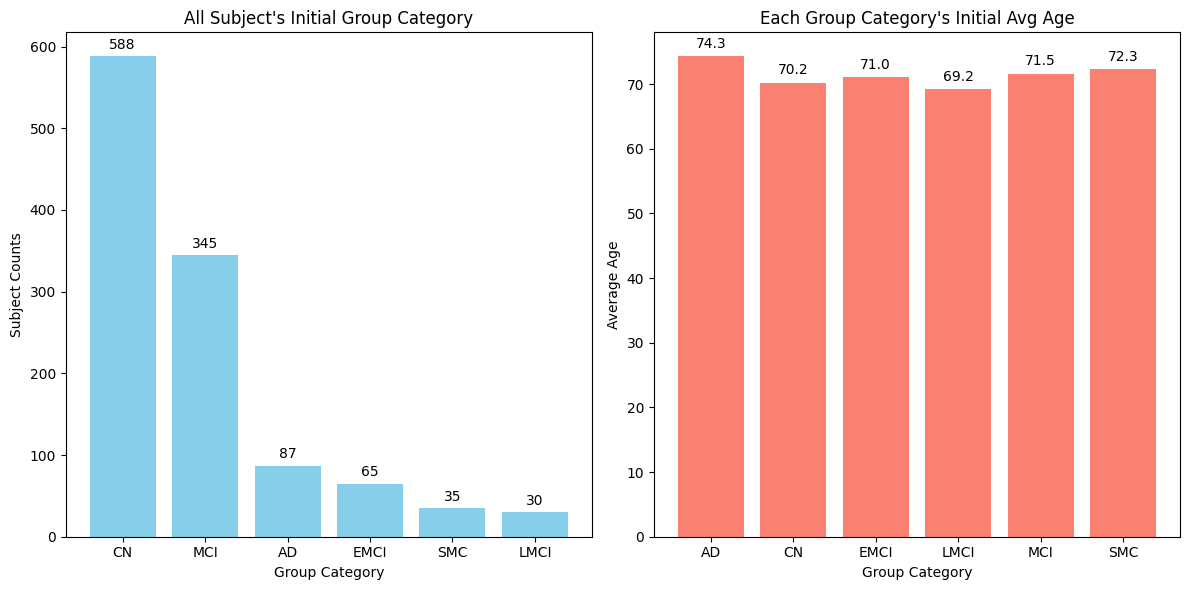

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Subject Counts per Group
ax1_counts = adni3_mri_first_entries['entry_research_group'].value_counts()
bars = ax1.bar(ax1_counts.index, ax1_counts.values, color='skyblue')
ax1.bar_label(bars, padding=3)
ax1.set_xlabel('Group Category')
ax1.set_ylabel('Subject Counts')
ax1.set_title("All Subject's Initial Group Category")

# Plot 2: Average Age per Group
ax2_avg_ages = adni3_mri_first_entries.groupby('entry_research_group').agg({'entry_age': 'mean'})
bars2 = ax2.bar(ax2_avg_ages.index, ax2_avg_ages['entry_age'], color='salmon')
ax2.bar_label(bars2, padding=4, fmt='%.1f')
ax2.set_xlabel('Group Category')
ax2.set_ylabel('Average Age')
ax2.set_title("Each Group Category's Initial Avg Age")

plt.tight_layout()
plt.show()

# --- CELL 7: SECTION 2 - MRI Imaging Exploratory Data Analysis ---

In [7]:
"""
Investigating the distribution of MRI modalities and scan descriptions.
"""
imaging_type_counts = imaging_df.groupby('Description').agg({
    'Subject': 'nunique'
}).sort_values(by='Subject', ascending=False).head(20).rename(columns={'Subject': 'Distinct Subjects'})

imaging_type_counts

,Distinct Subjects
Description,
Sagittal 3D FLAIR,1116
3 Plane Localizer,1020
Accelerated Sagittal MPRAGE,724
HighResHippocampus,712
Field Mapping,707
Axial T2 Star,599
Perfusion_Weighted,461
Axial 3D PASL (Eyes Open),442
Axial T2 STAR,314


# --- CELL 8: Filtering for High-Priority Longitudinal Scans ---

In [8]:
"""
For deep learning and longitudinal prediction, we prioritize:
1. Accelerated Sagittal MPRAGE (Structural atrophy)
2. HighResHippocampus (Memory center focus)
3. Sagittal 3D FLAIR (White matter lesions)
"""
target_scans = ['Accelerated Sagittal MPRAGE', 'HighResHippocampus', 'Sagittal 3D FLAIR']

# Filter and format dates
cleaned_imaging_df = imaging_df[imaging_df['Description'].isin(target_scans)].copy()
cleaned_imaging_df['Acq Date'] = pd.to_datetime(cleaned_imaging_df['Acq Date'])

# Calculate interval between scans per subject/modality
cleaned_imaging_df = cleaned_imaging_df.sort_values(by=['Subject', 'Description', 'Acq Date'])
cleaned_imaging_df['Time_Since_Last_Scan'] = cleaned_imaging_df.groupby(['Subject', 'Description'])['Acq Date'].diff().dt.days

# Verify uniqueness
if not cleaned_imaging_df.duplicated(subset=['Image Data ID', 'Subject']).any():
    print('Image Data ID & Subject features are unique.')

cleaned_imaging_df.head(10)

Image Data ID & Subject features are unique.


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Time_Since_Last_Scan
28793,I863056,002_S_0413,CN,F,87,init,MRI,Accelerated Sagittal MPRAGE,Original,2017-06-21,DCM,NaN,NaN
28779,I1221051,002_S_0413,CN,F,90,y2,MRI,Accelerated Sagittal MPRAGE,Original,2019-08-27,DCM,NaN,797.0
28797,I863061,002_S_0413,CN,F,87,init,MRI,HighResHippocampus,Original,2017-06-21,DCM,NaN,NaN
28786,I1221059,002_S_0413,CN,F,90,y2,MRI,HighResHippocampus,Original,2019-08-27,DCM,NaN,797.0
28796,I863060,002_S_0413,CN,F,87,init,MRI,Sagittal 3D FLAIR,Original,2017-06-21,DCM,NaN,NaN
28785,I1221058,002_S_0413,CN,F,90,y2,MRI,Sagittal 3D FLAIR,Original,2019-08-27,DCM,NaN,797.0
28746,I843510,002_S_1155,MCI,M,68,init,MRI,Accelerated Sagittal MPRAGE,Original,2017-04-24,DCM,NaN,NaN
28753,I995496,002_S_1155,MCI,M,69,y1,MRI,Accelerated Sagittal MPRAGE,Original,2018-05-08,DCM,NaN,379.0
28765,I1270004,002_S_1155,MCI,M,70,y2,MRI,Accelerated Sagittal MPRAGE,Original,2019-05-16,DCM,NaN,373.0
28750,I843515,002_S_1155,MCI,M,68,init,MRI,HighResHippocampus,Original,2017-04-24,DCM,NaN,NaN


# --- CELL 9: Longitudinal Imaging Cohort Analysis ---

In [9]:
# Grouping to see duration and count of scans per subject
imaging_analysis = cleaned_imaging_df.groupby(['Subject', 'Description']).agg({
    'Image Data ID': 'count',
    'Time_Since_Last_Scan': 'mean',
    'Acq Date': ['min', 'max']
})

# Flatten headers
imaging_analysis.columns = ['_'.join(col).strip() for col in imaging_analysis.columns.values]
imaging_analysis['duration_within_study'] = (imaging_analysis['Acq Date_max'] - imaging_analysis['Acq Date_min']).dt.days
imaging_analysis = imaging_analysis.reset_index()

imaging_analysis.head(10)

,Subject,Description,Image Data ID_count,Time_Since_Last_Scan_mean,Acq Date_min,Acq Date_max,duration_within_study
0,002_S_0413,Accelerated Sagittal MPRAGE,2,797.000000,2017-06-21,2019-08-27,797
1,002_S_0413,HighResHippocampus,2,797.000000,2017-06-21,2019-08-27,797
2,002_S_0413,Sagittal 3D FLAIR,2,797.000000,2017-06-21,2019-08-27,797
3,002_S_1155,Accelerated Sagittal MPRAGE,3,376.000000,2017-04-24,2019-05-16,752
4,002_S_1155,HighResHippocampus,4,250.666667,2017-04-24,2019-05-16,752
5,002_S_1155,Sagittal 3D FLAIR,3,376.000000,2017-04-24,2019-05-16,752
6,002_S_1261,Accelerated Sagittal MPRAGE,3,388.500000,2017-03-15,2019-05-01,777
7,002_S_1261,HighResHippocampus,3,388.500000,2017-03-15,2019-05-01,777
8,002_S_1261,Sagittal 3D FLAIR,3,388.500000,2017-03-15,2019-05-01,777
9,002_S_1280,Accelerated Sagittal MPRAGE,2,723.000000,2017-03-13,2019-03-06,723


# --- CELL 10: Visualization - Scan Frequency and Intervals ---

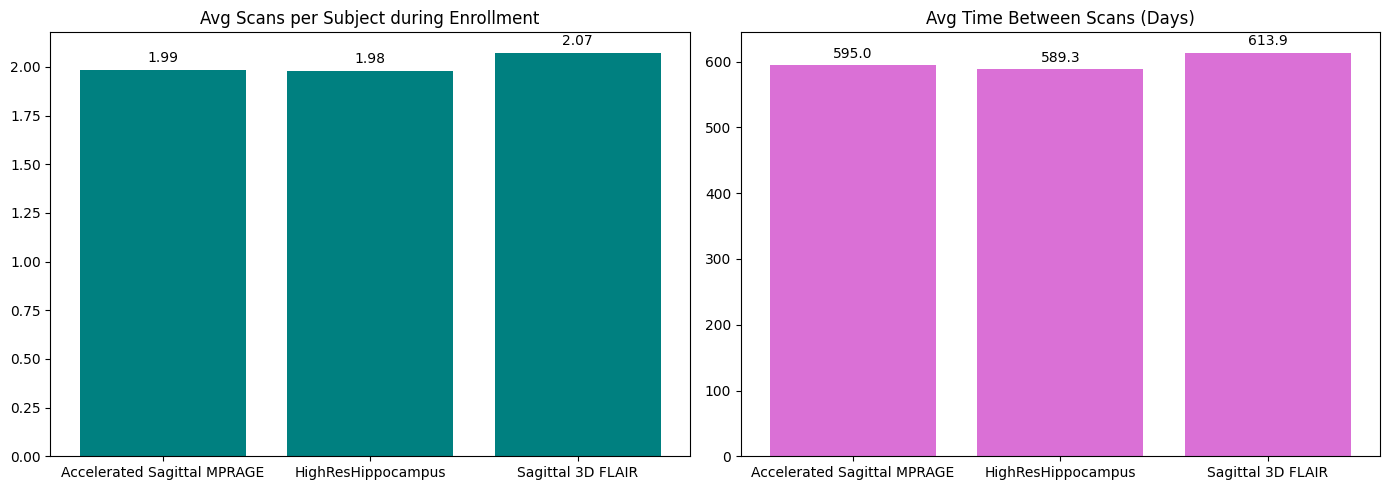

In [10]:
grouped_img_analysis = imaging_analysis.groupby('Description').agg({
    'Image Data ID_count': 'mean',
    'Time_Since_Last_Scan_mean': 'mean',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average count of scans
bars3 = ax1.bar(grouped_img_analysis.index, grouped_img_analysis['Image Data ID_count'], color='teal')
ax1.bar_label(bars3, padding=3, fmt='%.2f')
ax1.set_title('Avg Scans per Subject during Enrollment')

# Plot 2: Average time between scans
bars4 = ax2.bar(grouped_img_analysis.index, grouped_img_analysis['Time_Since_Last_Scan_mean'], color='orchid')
ax2.bar_label(bars4, padding=3, fmt='%.1f')
ax2.set_title('Avg Time Between Scans (Days)')

plt.tight_layout()
plt.show()

# --- Research / Scratch Work

In [11]:
"""
Preparing the target label (DIAGNOSIS) specifically for the ADNI3 phase.
"""
target_data = source_data['diagnosis'][source_data['diagnosis']['PHASE'] == "ADNI3"].copy()

# Filter for essential columns and remove duplicates
cleaned_target_data = target_data[['PHASE', 'PTID', 'EXAMDATE', 'DIAGNOSIS']].drop_duplicates()
cleaned_target_data['EXAMDATE'] = pd.to_datetime(cleaned_target_data['EXAMDATE'])
cleaned_target_data = cleaned_target_data.sort_values(by=['EXAMDATE'], ascending=[True])
cleaned_target_data.rename(columns={'PTID':'Subject_ID'}, inplace=True)
cleaned_target_data = cleaned_target_data.dropna()

# Resort cleaned_imaging_df in order to do mergeasof join
sorted_cleaned_imaging_df = cleaned_imaging_df.sort_values('Acq Date')
sorted_cleaned_imaging_df.rename(columns={'Subject':'Subject_ID'}, inplace=True)
# sorted_cleaned_imaging_df = sorted_cleaned_imaging_df.dropna()
# sorted_cleaned_imaging_df = sorted_cleaned_imaging_df[['Image Data ID', 'Subject_ID', 'Orig_Group', 'Sex' 'Age', 'M']]
sorted_cleaned_imaging_df.head()

print(f"Cleaned Diagnostic records for ADNI3: {len(cleaned_target_data)}")
cleaned_target_data[cleaned_target_data['EXAMDATE'].isnull()].head(10)

Cleaned Diagnostic records for ADNI3: 3476


,PHASE,Subject_ID,EXAMDATE,DIAGNOSIS


In [12]:
# Load your tables
mri_df = cleaned_imaging_df.copy() # From your notebook
adni_merge_df = source_data['target_v2'].copy() # From your notebook

# 1. Standardize the Patient ID column
mri_df = mri_df.rename(columns={'Subject': 'PTID'})

# 2. Convert to Datetime & Sort (Required for nearest-date merging)
mri_df['Acq Date'] = pd.to_datetime(mri_df['Acq Date']).dropna()
adni_merge_df['EXAMDATE'] = pd.to_datetime(adni_merge_df['EXAMDATE'], errors='coerce').dropna()

mri_df = mri_df.sort_values('Acq Date')
adni_merge_df = adni_merge_df.sort_values('EXAMDATE')

# 3. Perform the Nearest Date Merge (Notice we ignore the messy Visit codes entirely!)
final_labeled_data = pd.merge_asof(
    mri_df,
    adni_merge_df[['PTID', 'EXAMDATE', 'DX_bl', 'DX']], 
    left_on='Acq Date',
    right_on='EXAMDATE',
    by='PTID',             # Ensure we only match dates for the SAME patient
    direction='nearest',   # Find the closest EXAMDATE to the MRI Acq Date
    tolerance=pd.Timedelta(days=90) # Failsafe: Ensures we don't link an MRI to a visit a year away
)

final_labeled_data.head()

,Image Data ID,PTID,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Time_Since_Last_Scan,EXAMDATE,DX_bl,DX
0,I808817,027_S_6001,CN,F,72,sc,MRI,Sagittal 3D FLAIR,Original,2017-01-11,DCM,NaN,NaN,2017-01-19,SMC,CN
1,I812921,027_S_6002,MCI,M,72,sc,MRI,Sagittal 3D FLAIR,Original,2017-01-23,DCM,NaN,NaN,2017-02-02,LMCI,MCI
2,I812269,037_S_4302,LMCI,M,81,init,MRI,Sagittal 3D FLAIR,Original,2017-01-25,DCM,NaN,NaN,2017-01-25,LMCI,MCI
3,I812270,037_S_4302,LMCI,M,81,init,MRI,HighResHippocampus,Original,2017-01-25,DCM,NaN,NaN,2017-01-25,LMCI,MCI
4,I812263,037_S_4302,LMCI,M,81,init,MRI,Accelerated Sagittal MPRAGE,Original,2017-01-25,DCM,NaN,NaN,2017-01-25,LMCI,MCI


In [13]:
final_labeled_data.shape

(5162, 16)

In [14]:
final_labeled_data[final_labeled_data['DX'].isnull()]

,Image Data ID,PTID,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Time_Since_Last_Scan,EXAMDATE,DX_bl,DX
74,I847362,027_S_4869,LMCI,M,82,init,MRI,Sagittal 3D FLAIR,Original,2017-05-03,DCM,NaN,NaN,NaT,NaN,NaN
108,I858492,099_S_6025,CN,F,80,sc,MRI,Sagittal 3D FLAIR,Original,2017-06-02,DCM,NaN,NaN,NaT,NaN,NaN
155,I869388,027_S_5083,CN,M,78,init,MRI,Sagittal 3D FLAIR,Original,2017-06-29,DCM,NaN,NaN,NaT,NaN,NaN
199,I874816,037_S_6046,CN,M,76,sc,MRI,HighResHippocampus,Original,2017-07-17,DCM,NaN,NaN,NaT,NaN,NaN
200,I874817,037_S_6046,CN,M,76,sc,MRI,HighResHippocampus,Original,2017-07-17,DCM,NaN,0.0,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5157,I10281595,135_S_6544,MCI,F,83,y5,MRI,Sagittal 3D FLAIR,Original,2023-10-20,DCM,NaN,388.0,NaT,NaN,NaN
5158,I10929110,168_S_6821,MCI,F,76,y2,MRI,Accelerated Sagittal MPRAGE,Original,2023-12-14,DCM,NaN,1091.0,NaT,NaN,NaN
5159,I10929107,168_S_6821,MCI,F,76,y2,MRI,Sagittal 3D FLAIR,Original,2023-12-14,DCM,NaN,1091.0,NaT,NaN,NaN
5160,I10929096,168_S_6821,MCI,F,76,y2,MRI,HighResHippocampus,Original,2023-12-14,DCM,NaN,0.0,NaT,NaN,NaN


In [15]:
# Load your tables
mri_df = cleaned_imaging_df.copy() # From your notebook
dxsum_merge_df = source_data['target_v1'].copy() # From your notebook

# 1. Standardize the Patient ID column
mri_df = mri_df.rename(columns={'Subject': 'PTID'})

# 2. Convert to Datetime & Sort (Required for nearest-date merging)
mri_df['Acq Date'] = pd.to_datetime(mri_df['Acq Date'])
dxsum_merge_df['EXAMDATE'] = pd.to_datetime(dxsum_merge_df['EXAMDATE'], errors='coerce')

mri_df = mri_df.sort_values('Acq Date')
dxsum_merge_df = dxsum_merge_df.sort_values('EXAMDATE')

mri_df = mri_df.dropna(subset=['Acq Date', 'PTID'])
dxsum_merge_df = dxsum_merge_df.dropna(subset=['EXAMDATE', 'PTID', 'DIAGNOSIS'])

# 3. Perform the Nearest Date Merge (Notice we ignore the messy Visit codes entirely!)
final_labeled_data_dxsum = pd.merge_asof(
    mri_df,
    dxsum_merge_df[['PTID', 'EXAMDATE', 'DIAGNOSIS']], 
    left_on='Acq Date',
    right_on='EXAMDATE',
    by='PTID',             # Ensure we only match dates for the SAME patient
    direction='nearest',   # Find the closest EXAMDATE to the MRI Acq Date
    tolerance=pd.Timedelta(days=90) # Failsafe: Ensures we don't link an MRI to a visit a year away
)

final_labeled_data_dxsum.head()

,Image Data ID,PTID,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Time_Since_Last_Scan,EXAMDATE,DIAGNOSIS
0,I808817,027_S_6001,CN,F,72,sc,MRI,Sagittal 3D FLAIR,Original,2017-01-11,DCM,NaN,NaN,2017-01-19,1.0
1,I812921,027_S_6002,MCI,M,72,sc,MRI,Sagittal 3D FLAIR,Original,2017-01-23,DCM,NaN,NaN,2017-02-02,2.0
2,I812269,037_S_4302,LMCI,M,81,init,MRI,Sagittal 3D FLAIR,Original,2017-01-25,DCM,NaN,NaN,2017-02-04,2.0
3,I812270,037_S_4302,LMCI,M,81,init,MRI,HighResHippocampus,Original,2017-01-25,DCM,NaN,NaN,2017-02-04,2.0
4,I812263,037_S_4302,LMCI,M,81,init,MRI,Accelerated Sagittal MPRAGE,Original,2017-01-25,DCM,NaN,NaN,2017-02-04,2.0


In [16]:
final_labeled_data_dxsum.shape

(5162, 15)

In [17]:
final_labeled_data_dxsum[final_labeled_data_dxsum['DIAGNOSIS'].isnull()]

,Image Data ID,PTID,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Time_Since_Last_Scan,EXAMDATE,DIAGNOSIS
73,I848161,022_S_2379,EMCI,M,72,init,MRI,Accelerated Sagittal MPRAGE,Original,2017-05-03,DCM,NaN,NaN,NaT,NaN
74,I847362,027_S_4869,LMCI,M,82,init,MRI,Sagittal 3D FLAIR,Original,2017-05-03,DCM,NaN,NaN,NaT,NaN
77,I848167,022_S_2379,EMCI,M,72,init,MRI,HighResHippocampus,Original,2017-05-03,DCM,NaN,NaN,NaT,NaN
79,I848166,022_S_2379,EMCI,M,72,init,MRI,Sagittal 3D FLAIR,Original,2017-05-03,DCM,NaN,NaN,NaT,NaN
81,I849457,130_S_4343,CN,M,85,init,MRI,Sagittal 3D FLAIR,Original,2017-05-09,DCM,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5096,I1663443,041_S_6354,CN,F,76,y4,MRI,Accelerated Sagittal MPRAGE,Original,2023-01-23,DCM,NaN,830.0,NaT,NaN
5158,I10929110,168_S_6821,MCI,F,76,y2,MRI,Accelerated Sagittal MPRAGE,Original,2023-12-14,DCM,NaN,1091.0,NaT,NaN
5159,I10929107,168_S_6821,MCI,F,76,y2,MRI,Sagittal 3D FLAIR,Original,2023-12-14,DCM,NaN,1091.0,NaT,NaN
5160,I10929096,168_S_6821,MCI,F,76,y2,MRI,HighResHippocampus,Original,2023-12-14,DCM,NaN,0.0,NaT,NaN


In [18]:
import pandas as pd
import numpy as np

# ==========================================
# 0. Data Extraction (Using your source_data)
# ==========================================
base_entry_df = source_data['first_subject_entry'].copy()
imaging_df = source_data['imaging'].copy()
adnimerge_df = source_data['target_v2'].copy()
dxsum_df = source_data['diagnosis'].copy()


# base cleaning to adni3 mri imaging patients only
adni3_unique_subs = imaging_df['Subject'].unique()
print(f"{len(adni3_unique_subs)} distinct subjects within ADNI3 imaging data")

# Flagging subjects in the entry dataframe who have corresponding MRI data
base_entry_df['isin_mri_adni3'] = base_entry_df['subject_id'].isin(adni3_unique_subs)
base_entry_df = base_entry_df[base_entry_df['isin_mri_adni3']]

# ==========================================
# 1. Base Population ("From" State)
# ==========================================
base_pop = base_entry_df[['subject_id', 'entry_research_group']].copy()
base_pop = base_pop.rename(columns={'subject_id': 'PTID'})

# Helper function to standardize ADNI's diverse diagnostic text/numeric variants into core classes
def standardize_dx(dx):
    if pd.isna(dx): 
        return np.nan
    dx_str = str(dx).strip().upper()
    if dx_str in ['1', '1.0', 'CN', 'SMC', 'NORMAL', 'CU']: 
        return 'CN'
    if dx_str in ['2', '2.0', 'MCI', 'EMCI', 'LMCI']: 
        return 'MCI'
    if dx_str in ['3', '3.0', 'AD', 'DEMENTIA']: 
        return 'AD'
    
    # Substring fallbacks
    if 'CN' in dx_str or 'NORMAL' in dx_str: return 'CN'
    if 'MCI' in dx_str: return 'MCI'
    if 'AD' in dx_str or 'DEMENTIA' in dx_str: return 'AD'
    return np.nan

base_pop['from_state'] = base_pop['entry_research_group'].apply(standardize_dx)

# ==========================================
# 2. Latest Diagnosis ("To" State)
# ==========================================
dxsum_clean = dxsum_df.dropna(subset=['PTID', 'EXAMDATE', 'DIAGNOSIS']).copy()
dxsum_clean['EXAMDATE'] = pd.to_datetime(dxsum_clean['EXAMDATE'], errors='coerce')
dxsum_clean = dxsum_clean.dropna(subset=['EXAMDATE'])

# Sort chronologically to get the absolute most recent/final diagnosis per patient
latest_dx = dxsum_clean.sort_values(by=['PTID', 'EXAMDATE']).groupby('PTID').last().reset_index()
latest_dx['to_state'] = latest_dx['DIAGNOSIS'].apply(standardize_dx)

# Merge the initial (from) and final (to) states to map patient evolution
transitions = pd.merge(base_pop, latest_dx[['PTID', 'to_state']], on='PTID', how='inner')
transitions = transitions.dropna(subset=['from_state', 'to_state'])

# ==========================================
# 3. Tabular Data Check
# ==========================================
# Flag patients if their ID exists in the ADNIMERGE tabular dataset
tabular_ptids = set(adnimerge_df['PTID'].dropna().unique())
transitions['has_tabular'] = transitions['PTID'].isin(tabular_ptids)

# ==========================================
# 4. Cumulative Imaging Buckets
# ==========================================
# Calculate the total number of distinct imaging records available per patient
img_counts = imaging_df.groupby('Subject').size().reset_index(name='total_images')
img_counts = img_counts.rename(columns={'Subject': 'PTID'})

# Join image counts to our main transition table (filling zero for patients without imaging)
transitions = pd.merge(transitions, img_counts, on='PTID', how='left')
transitions['total_images'] = transitions['total_images'].fillna(0)

# ==========================================
# 5. Populate Final Summary Table
# ==========================================
# Explicit definitions to match the exact row labels and order requested from the image
# Note: 'MCI->CN' intentionally lacks spacing around the arrow to mirror your image snippet.
evolutions_to_track = [
    ('CN', 'CN', 'CN -> CN'),
    ('CN', 'MCI', 'CN -> MCI'),
    ('CN', 'AD', 'CN -> AD'),
    ('MCI', 'MCI', 'MCI -> MCI'),
    ('MCI', 'AD', 'MCI -> AD'),
    ('AD', 'AD', 'AD -> AD'),
    ('MCI', 'CN', 'MCI->CN')  
]

summary_data = []

for from_dx, to_dx, row_label in evolutions_to_track:
    # Subset patients matching this specific evolution transition
    subset = transitions[(transitions['from_state'] == from_dx) & (transitions['to_state'] == to_dx)]
    
    # Calculate aggregation counts / cumulative buckets directly to expected headers
    summary_data.append({
        'Evolution': row_label,
        '# pt diagnosed': len(subset),
        '# pt with tabular data': subset['has_tabular'].sum(),
        '# pt with 1+ image': (subset['total_images'] >= 1).sum(),
        '# pt with 2+ image': (subset['total_images'] >= 2).sum(),
        '# pt with 3+ image': (subset['total_images'] >= 3).sum(),
        '# pt with 4+ image': (subset['total_images'] >= 4).sum()
    })

# Form Output
summary_table = pd.DataFrame(summary_data)

print("ADNI3")
display(summary_table)

1150 distinct subjects within ADNI3 imaging data
ADNI3


,Evolution,# pt diagnosed,# pt with tabular data,# pt with 1+ image,# pt with 2+ image,# pt with 3+ image,# pt with 4+ image
0,CN -> CN,534,482,534,534,534,534
1,CN -> MCI,65,65,65,65,65,65
2,CN -> AD,24,24,24,24,24,24
3,MCI -> MCI,287,237,287,287,287,287
4,MCI -> AD,93,93,93,93,93,93
5,AD -> AD,85,69,85,85,85,85
6,MCI->CN,60,59,60,60,60,60


In [19]:
import pandas as pd
import numpy as np

# Try to import display for nice formatting in Jupyter Notebooks
try:
    from IPython.display import display
except ImportError:
    pass

# ==========================================
# 0. Data Extraction (Using your source_data)
# ==========================================
base_entry_df = source_data['first_subject_entry'] # uses all ADNIs
imaging_df = source_data['all_imaging'] # uses all ADNIs
adnimerge_df = source_data['target_v2'] # uses only ADNIs GO, 1, 2, 3
dxsum_df = source_data['diagnosis'] # uses all ADNIs


'''
# base cleaning to adni3 mri imaging patients only
adni3_unique_subs = imaging_df['Subject'].unique()
print(f"{len(adni3_unique_subs)} distinct subjects within ADNI3 imaging data")

# Flagging subjects in the entry dataframe who have corresponding MRI data
base_entry_df['isin_mri_adni3'] = base_entry_df['subject_id'].isin(adni3_unique_subs)
base_entry_df = base_entry_df[base_entry_df['isin_mri_adni3']]
'''

# ==========================================
# 1. Base Population & Diagnoses ("From" & "To" States)
# ==========================================
base_pop = base_entry_df[['subject_id', 'entry_research_group']].copy()
base_pop = base_pop.rename(columns={'subject_id': 'PTID'})

# Helper function to standardize ADNI's diverse diagnostic text/numeric variants into core classes
def standardize_dx(dx):
    if pd.isna(dx): 
        return np.nan
    dx_str = str(dx).strip().upper()
    if dx_str in ['1', '1.0', 'CN', 'SMC', 'NORMAL', 'CU']: return 'CN'
    if dx_str in ['2', '2.0', 'MCI', 'EMCI', 'LMCI']: return 'MCI'
    if dx_str in ['3', '3.0', 'AD', 'DEMENTIA']: return 'AD'
    
    # Substring fallbacks
    if 'CN' in dx_str or 'NORMAL' in dx_str: return 'CN'
    if 'MCI' in dx_str: return 'MCI'
    if 'AD' in dx_str or 'DEMENTIA' in dx_str: return 'AD'
    return np.nan

base_pop['from_state'] = base_pop['entry_research_group'].apply(standardize_dx)

dxsum_clean = dxsum_df.dropna(subset=['PTID', 'EXAMDATE', 'DIAGNOSIS']).copy()
dxsum_clean['EXAMDATE'] = pd.to_datetime(dxsum_clean['EXAMDATE'], errors='coerce')
dxsum_clean = dxsum_clean.dropna(subset=['EXAMDATE'])

# Sort chronologically to get the absolute most recent/final diagnosis per patient
latest_dx = dxsum_clean.sort_values(by=['PTID', 'EXAMDATE']).groupby('PTID').last().reset_index()
latest_dx['to_state'] = latest_dx['DIAGNOSIS'].apply(standardize_dx)

# Merge the initial (from) and final (to) states to map patient evolution
transitions = pd.merge(base_pop, latest_dx[['PTID', 'to_state']], on='PTID', how='inner')
transitions = transitions.dropna(subset=['from_state', 'to_state'])

# ==========================================
# 2. Tabular Data Check
# ==========================================
# Flag patients if their ID exists in the ADNIMERGE tabular dataset
tabular_ptids = set(adnimerge_df['PTID'].dropna().unique())
transitions['has_tabular'] = transitions['PTID'].isin(tabular_ptids)

# ==========================================
# 3. Generate 3 Tables for Target Scans
# ==========================================
target_scans = ['Accelerated Sagittal MPRAGE', 'HighResHippocampus', 'Sagittal 3D FLAIR']

# Explicit definitions to match the exact row labels and order requested from the image
evolutions_to_track = [
    ('CN', 'CN', 'CN -> CN'),
    ('CN', 'MCI', 'CN -> MCI'),
    ('CN', 'AD', 'CN -> AD'),
    ('MCI', 'MCI', 'MCI -> MCI'),
    ('MCI', 'AD', 'MCI -> AD'),
    ('AD', 'AD', 'AD -> AD'),
    ('MCI', 'CN', 'MCI->CN')  
]

# Dictionary to optionally save the individual dataframes if you need them later in the notebook
scan_summary_tables = {}

# Loop through each scan type and generate its respective table
for scan_type in target_scans:
    
    # 3a. Filter imaging records down to strictly this scan description
    specific_imaging_df = imaging_df[imaging_df['Description'] == scan_type]
    
    # 3b. Calculate the total number of distinct imaging records for THIS scan type per patient
    img_counts = specific_imaging_df.groupby('Subject').size().reset_index(name='total_images')
    img_counts = img_counts.rename(columns={'Subject': 'PTID'})
    
    # Join specific image counts to our main transition table (filling zero for patients without this scan)
    temp_transitions = pd.merge(transitions, img_counts, on='PTID', how='left')
    temp_transitions['total_images'] = temp_transitions['total_images'].fillna(0)
    
    summary_data = []

    # 3c. Calculate Metrics per Evolution Group
    for from_dx, to_dx, row_label in evolutions_to_track:
        # Subset patients matching this specific evolution transition
        subset = temp_transitions[(temp_transitions['from_state'] == from_dx) & (temp_transitions['to_state'] == to_dx)]
        
        # Calculate aggregation counts / cumulative buckets directly to expected headers
        summary_data.append({
            'Evolution': row_label,
            '# pt diagnosed': len(subset),  # Base counts remain unchanged across tables
            '# pt with tabular data': subset['has_tabular'].sum(), # Base tabular counts remain unchanged
            '# pt with 1+ image': (subset['total_images'] >= 1).sum(),
            '# pt with 2+ image': (subset['total_images'] >= 2).sum(),
            '# pt with 3+ image': (subset['total_images'] >= 3).sum(),
            '# pt with 4+ image': (subset['total_images'] >= 4).sum()
        })

    # 3d. Build output dataframe and display
    summary_table = pd.DataFrame(summary_data)
    scan_summary_tables[scan_type] = summary_table  # Save table to dictionary
    
    # Print a distinct header and display the data block cleanly in Jupyter Notebooks
    print(f"\n==========================================")
    print(f"ADNI - Modality: {scan_type}")
    print(f"==========================================")
    
    try:
        display(summary_table)
    except NameError:
        print(summary_table)


ADNI - Modality: Accelerated Sagittal MPRAGE


,Evolution,# pt diagnosed,# pt with tabular data,# pt with 1+ image,# pt with 2+ image,# pt with 3+ image,# pt with 4+ image
0,CN -> CN,1348,741,356,189,103,19
1,CN -> MCI,120,117,39,27,15,6
2,CN -> AD,45,45,14,9,7,4
3,MCI -> MCI,1083,639,176,80,46,22
4,MCI -> AD,399,395,52,40,22,14
5,AD -> AD,534,405,51,25,12,2
6,MCI->CN,86,81,37,24,18,12



ADNI - Modality: HighResHippocampus


,Evolution,# pt diagnosed,# pt with tabular data,# pt with 1+ image,# pt with 2+ image,# pt with 3+ image,# pt with 4+ image
0,CN -> CN,1348,741,352,184,89,21
1,CN -> MCI,120,117,38,26,16,4
2,CN -> AD,45,45,14,9,7,3
3,MCI -> MCI,1083,639,172,83,46,30
4,MCI -> AD,399,395,51,37,20,11
5,AD -> AD,534,405,49,23,13,3
6,MCI->CN,86,81,37,24,17,12



ADNI - Modality: Sagittal 3D FLAIR


,Evolution,# pt diagnosed,# pt with tabular data,# pt with 1+ image,# pt with 2+ image,# pt with 3+ image,# pt with 4+ image
0,CN -> CN,1348,741,522,288,156,33
1,CN -> MCI,120,117,64,47,29,11
2,CN -> AD,45,45,24,19,11,6
3,MCI -> MCI,1083,639,276,137,86,47
4,MCI -> AD,399,395,90,66,39,22
5,AD -> AD,534,405,82,41,20,5
6,MCI->CN,86,81,60,40,27,20


In [20]:
import pandas as pd
import numpy as np
import re

# Try to import display for nice formatting in Jupyter Notebooks
try:
    from IPython.display import display
except ImportError:
    pass

# ==========================================
# 0. Data Extraction (Updated Data Source)
# ==========================================
base_entry_df = source_data['first_subject_entry']
imaging_df = source_data['adni_imaging_csv_all']  # Updated dataframe with all phases
adnimerge_df = source_data['target_v2']
dxsum_df = source_data['diagnosis']

# ==========================================
# 1. Base Population & Diagnoses ("From" & "To" States)
# ==========================================
base_pop = base_entry_df[['subject_id', 'entry_research_group']].copy()
base_pop = base_pop.rename(columns={'subject_id': 'PTID'})

# Helper function to standardize ADNI's diverse diagnostic text/numeric variants into core classes
def standardize_dx(dx):
    if pd.isna(dx): 
        return np.nan
    dx_str = str(dx).strip().upper()
    if dx_str in ['1', '1.0', 'CN', 'SMC', 'NORMAL', 'CU']: return 'CN'
    if dx_str in ['2', '2.0', 'MCI', 'EMCI', 'LMCI']: return 'MCI'
    if dx_str in ['3', '3.0', 'AD', 'DEMENTIA']: return 'AD'
    
    # Substring fallbacks
    if 'CN' in dx_str or 'NORMAL' in dx_str: return 'CN'
    if 'MCI' in dx_str: return 'MCI'
    if 'AD' in dx_str or 'DEMENTIA' in dx_str: return 'AD'
    return np.nan

base_pop['from_state'] = base_pop['entry_research_group'].apply(standardize_dx)

dxsum_clean = dxsum_df.dropna(subset=['PTID', 'EXAMDATE', 'DIAGNOSIS']).copy()
dxsum_clean['EXAMDATE'] = pd.to_datetime(dxsum_clean['EXAMDATE'], errors='coerce')
dxsum_clean = dxsum_clean.dropna(subset=['EXAMDATE'])

# Sort chronologically to get the absolute most recent/final diagnosis per patient
latest_dx = dxsum_clean.sort_values(by=['PTID', 'EXAMDATE']).groupby('PTID').last().reset_index()
latest_dx['to_state'] = latest_dx['DIAGNOSIS'].apply(standardize_dx)

# Merge the initial (from) and final (to) states to map patient evolution
transitions = pd.merge(base_pop, latest_dx[['PTID', 'to_state']], on='PTID', how='inner')
transitions = transitions.dropna(subset=['from_state', 'to_state'])

# ==========================================
# 2. Tabular Data Check
# ==========================================
# Flag patients if their ID exists in the ADNIMERGE tabular dataset
tabular_ptids = set(adnimerge_df['PTID'].dropna().unique())
transitions['has_tabular'] = transitions['PTID'].isin(tabular_ptids)

# ==========================================
# 3. Generate 3 Tables using Regex Pattern Matching
# ==========================================
# Define the imaging categories and their respective regex patterns
# - 'MP-?RAGE' matches "MPRAGE" and "MP-RAGE" (the '?' means the hyphen is optional)
imaging_categories = {
    'MPRAGE': r'MP-?RAGE',
    'FLAIR': r'FLAIR',
    'Hippocampus': r'HIPPOCAMPUS'
}

# Explicit definitions to match the exact row labels and order requested from the image
evolutions_to_track = [
    ('CN', 'CN', 'CN -> CN'),
    ('CN', 'MCI', 'CN -> MCI'),
    ('CN', 'AD', 'CN -> AD'),
    ('MCI', 'MCI', 'MCI -> MCI'),
    ('MCI', 'AD', 'MCI -> AD'),
    ('AD', 'AD', 'AD -> AD'),
    ('MCI', 'CN', 'MCI->CN')  
]

scan_summary_tables = {}

# Identify which column contains the subject ID in the new imaging dataframe
# (Fallback to 'PTID' just in case the new all-phases dataset named it differently than 'Subject')
subject_col = 'Subject' if 'Subject' in imaging_df.columns else 'PTID'

# Loop through each scan category and its regex pattern
for category_name, regex_pattern in imaging_categories.items():
    
    # 3a. Filter imaging records using Regex (case-insensitive, dropping NaNs safely)
    mask = imaging_df['Description'].str.contains(regex_pattern, case=False, na=False, regex=True)
    specific_imaging_df = imaging_df[mask]
    
    # 3b. Calculate the total number of distinct imaging records for THIS category per patient
    img_counts = specific_imaging_df.groupby(subject_col).size().reset_index(name='total_images')
    img_counts = img_counts.rename(columns={subject_col: 'PTID'})
    
    # Join specific image counts to our main transition table (filling zero for patients without this scan)
    temp_transitions = pd.merge(transitions, img_counts, on='PTID', how='left')
    temp_transitions['total_images'] = temp_transitions['total_images'].fillna(0)
    
    summary_data = []

    # 3c. Calculate Metrics per Evolution Group
    for from_dx, to_dx, row_label in evolutions_to_track:
        # Subset patients matching this specific evolution transition
        subset = temp_transitions[(temp_transitions['from_state'] == from_dx) & (temp_transitions['to_state'] == to_dx)]
        
        # Calculate aggregation counts / cumulative buckets directly to expected headers
        summary_data.append({
            'Evolution': row_label,
            '# pt diagnosed': len(subset), 
            '# pt with tabular data': subset['has_tabular'].sum(), 
            '# pt with 1+ image': (subset['total_images'] >= 1).sum(),
            '# pt with 2+ image': (subset['total_images'] >= 2).sum(),
            '# pt with 3+ image': (subset['total_images'] >= 3).sum(),
            '# pt with 4+ image': (subset['total_images'] >= 4).sum()
        })

    # 3d. Build output dataframe and display
    summary_table = pd.DataFrame(summary_data)
    scan_summary_tables[category_name] = summary_table  
    
    # Print a distinct header and display the data block cleanly
    print(f"\n=======================================================")
    print(f"ADNI (All Phases) - Imaging Category: {category_name}")
    print(f"Regex Pattern Used: '{regex_pattern}'")
    print(f"=======================================================")
    
    try:
        display(summary_table)
    except NameError:
        print(summary_table.to_string(index=False))


ADNI (All Phases) - Imaging Category: MPRAGE
Regex Pattern Used: 'MP-?RAGE'


,Evolution,# pt diagnosed,# pt with tabular data,# pt with 1+ image,# pt with 2+ image,# pt with 3+ image,# pt with 4+ image
0,CN -> CN,1348,741,1043,691,454,392
1,CN -> MCI,120,117,98,94,89,81
2,CN -> AD,45,45,41,40,39,39
3,MCI -> MCI,1083,639,845,636,464,421
4,MCI -> AD,399,395,361,358,342,329
5,AD -> AD,534,405,416,348,283,268
6,MCI->CN,86,81,81,79,72,65



ADNI (All Phases) - Imaging Category: FLAIR
Regex Pattern Used: 'FLAIR'


,Evolution,# pt diagnosed,# pt with tabular data,# pt with 1+ image,# pt with 2+ image,# pt with 3+ image,# pt with 4+ image
0,CN -> CN,1348,741,1024,520,387,274
1,CN -> MCI,120,117,92,85,70,52
2,CN -> AD,45,45,33,30,25,21
3,MCI -> MCI,1083,639,791,476,363,306
4,MCI -> AD,399,395,203,190,172,151
5,AD -> AD,534,405,297,185,139,102
6,MCI->CN,86,81,76,73,66,58



ADNI (All Phases) - Imaging Category: Hippocampus
Regex Pattern Used: 'HIPPOCAMPUS'


,Evolution,# pt diagnosed,# pt with tabular data,# pt with 1+ image,# pt with 2+ image,# pt with 3+ image,# pt with 4+ image
0,CN -> CN,1348,741,652,244,139,62
1,CN -> MCI,120,117,45,34,23,12
2,CN -> AD,45,45,15,9,8,5
3,MCI -> MCI,1083,639,358,146,66,42
4,MCI -> AD,399,395,59,47,31,16
5,AD -> AD,534,405,94,33,15,5
6,MCI->CN,86,81,42,34,22,13
